In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
%matplotlib inline


In [23]:
housing = pd.read_csv(r'C:\Users\yuvra\onedrive\desktop\python\machine_learning\data\housing.csv')
print(housing.head(),'/n',housing.shape)

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY   /n (20640, 10)


In [26]:
housing.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

In [39]:
print(housing.isnull().sum())
print(housing.isna())
print(housing.fillna(0))

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64
       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0          False     False               False        False           False   
1          False     False               False        False           False   
2          False     False               False        False           False   
3          False     False               False        False           False   
4          False     False               False        False           False   
...          ...       ...                 ...          ...             ...   
20635      False     False               False        False           False   
20636      False     False               False        False           False   
20637      False

In [46]:
print(housing.columns[9])

ocean_proximity


In [41]:
# Check which columns are non-numeric
print(housing.dtypes)
print(housing.select_dtypes(include=['object']).columns)

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object
Index(['ocean_proximity'], dtype='object')


In [50]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
housing['ocean_proximity']=le.fit_transform(housing['ocean_proximity'])


In [51]:
housing.corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967,-0.289779
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160,0.200974
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623,0.112468
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153,-0.015693
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686,-0.014768
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650,-0.070282
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843,-0.018186
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075,-0.014957
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000,0.081750
ocean_proximity,-0.289779,0.200974,0.112468,-0.015693,-0.014768,-0.070282,-0.018186,-0.014957,0.081750,1.000000


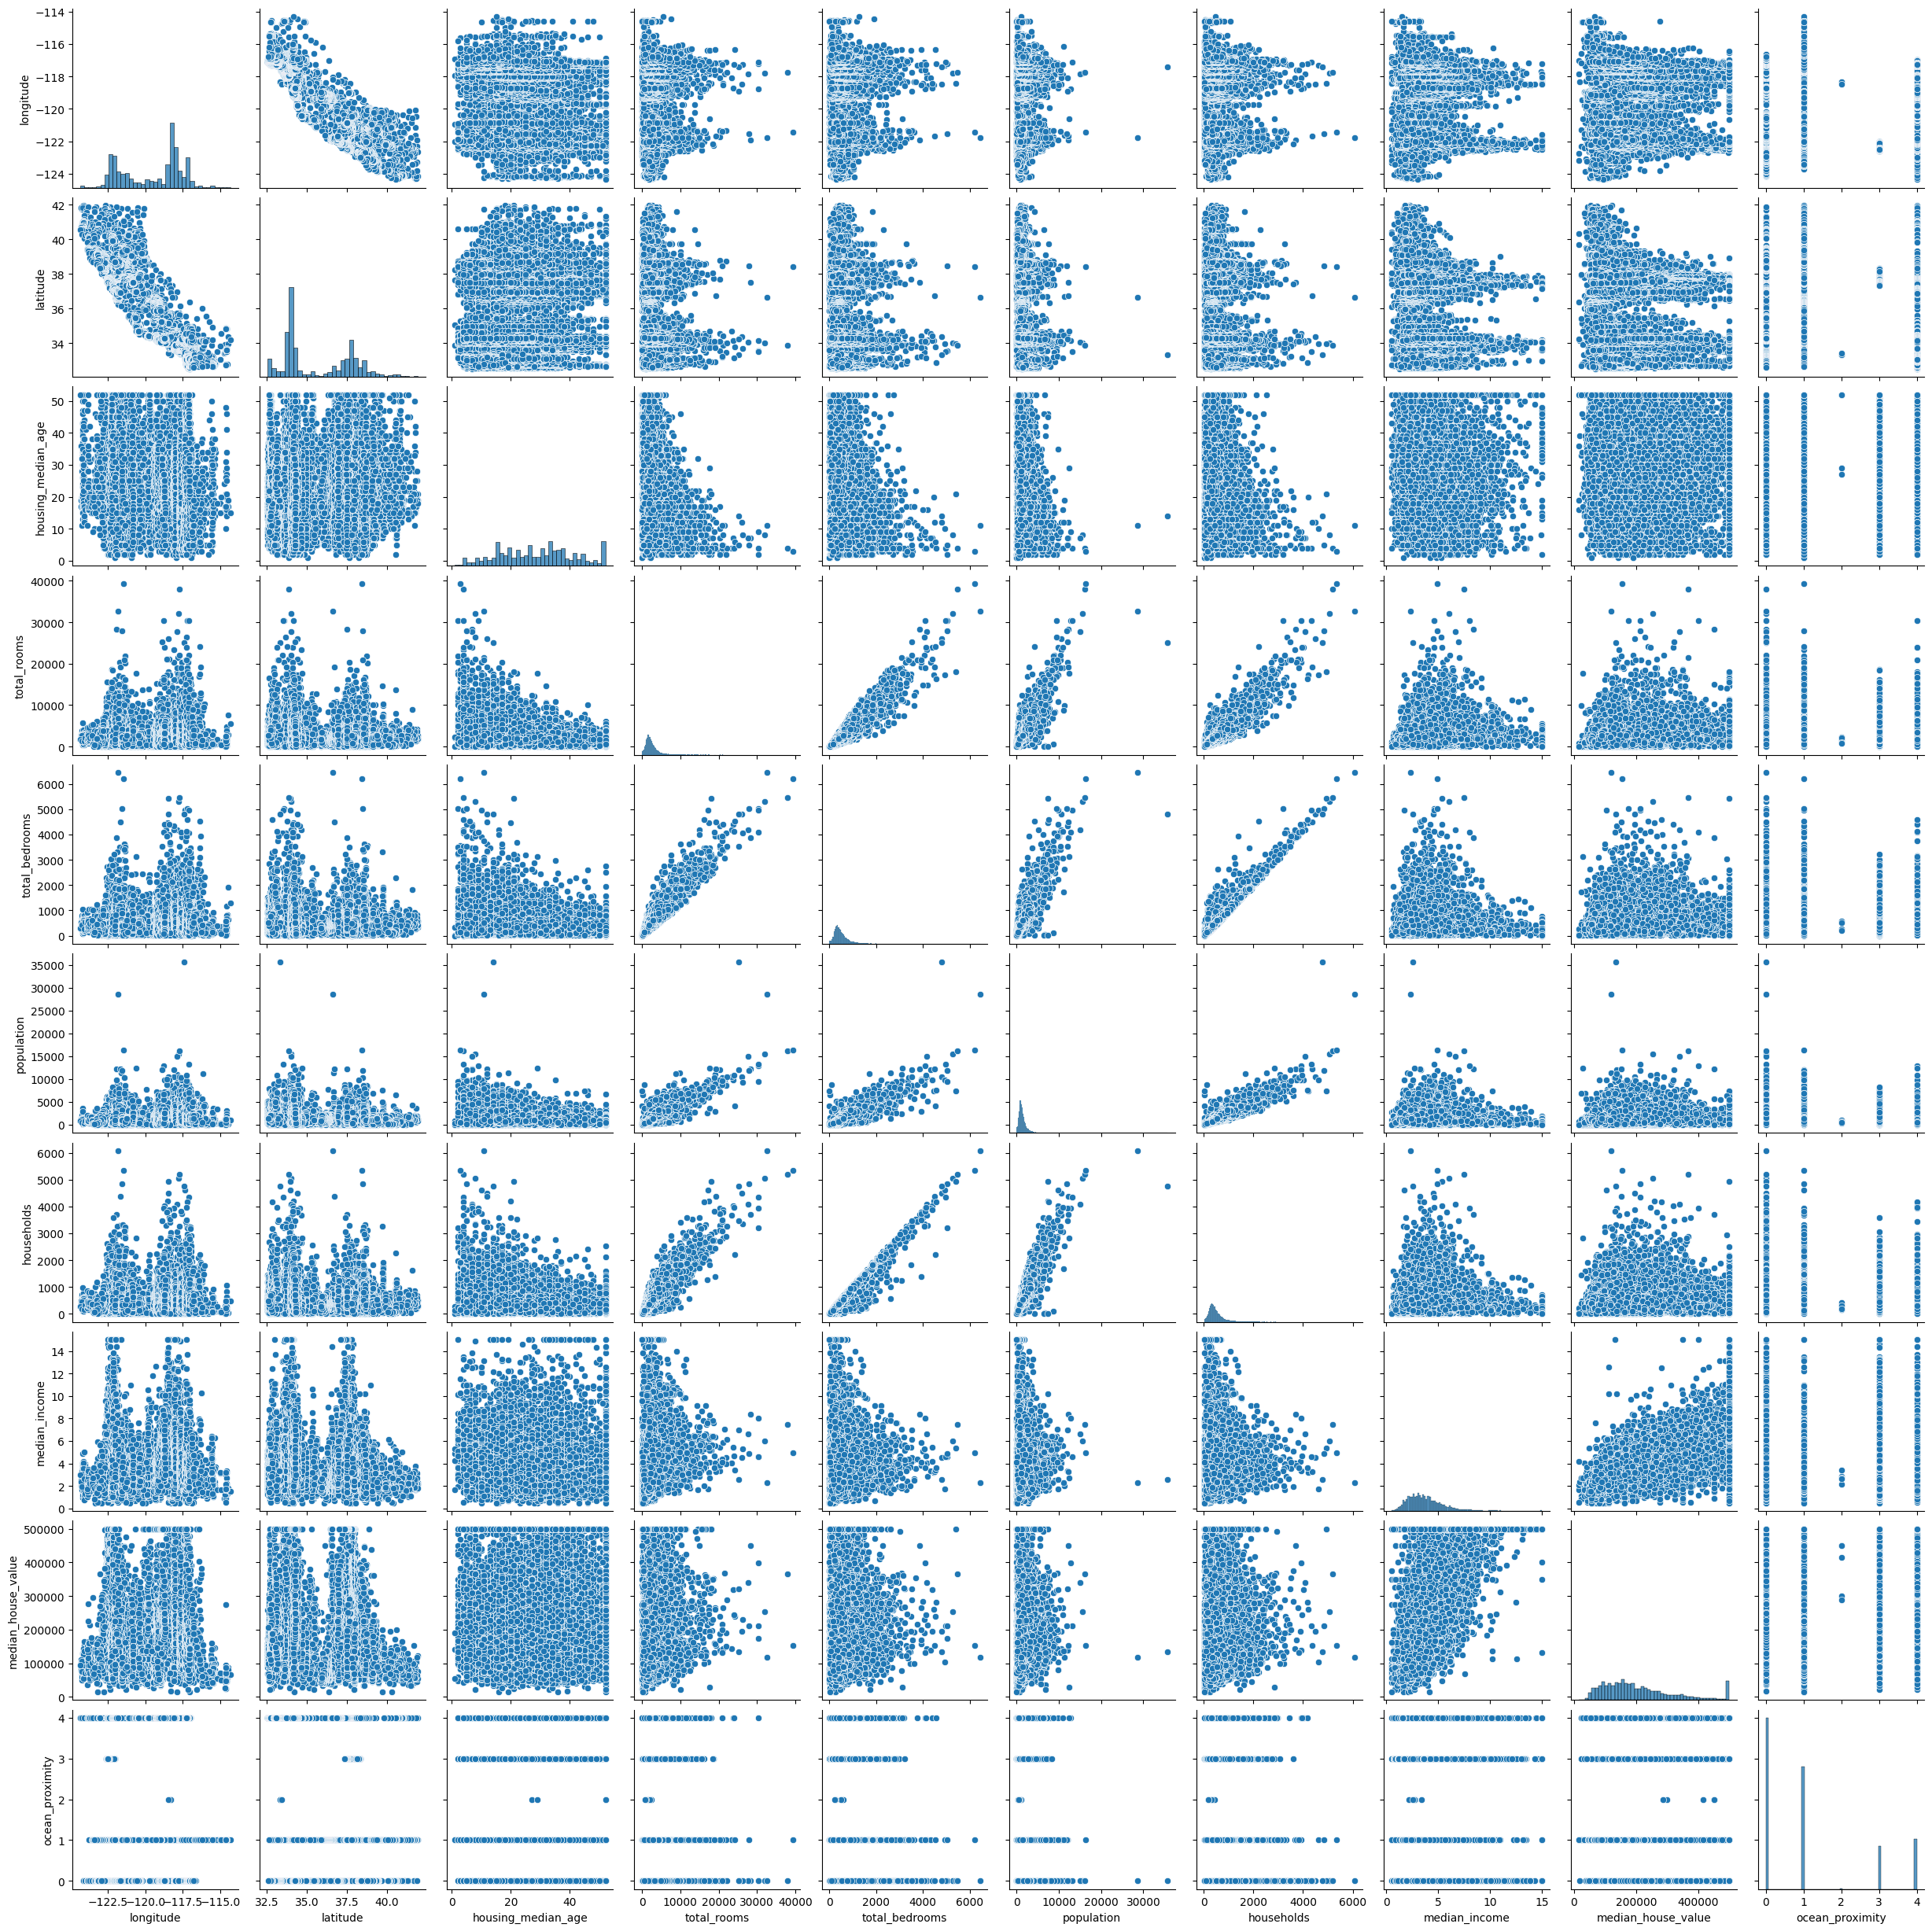

In [52]:
sns.pairplot(housing)

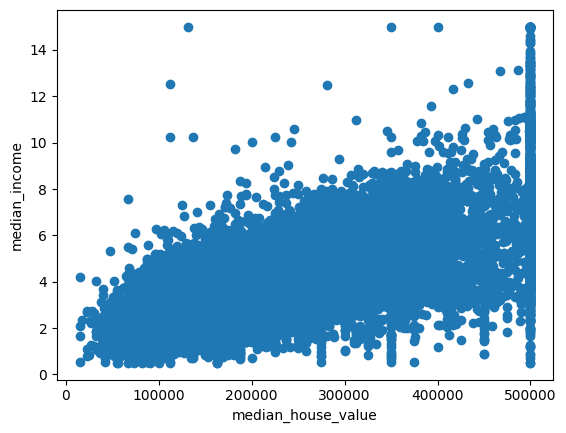

In [54]:
#scatter ploting
line=plt.scatter(housing['median_house_value'],housing['median_income'])
plt.xlabel('median_house_value')
plt.ylabel('median_income')
print(line)

In [61]:
housing.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity         int64
dtype: object

In [63]:
X=housing['median_house_value']
y=housing['median_income']

In [65]:
X.shape

(20640,)

In [66]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=56)

In [71]:
X_train=X_train.to_frame()
X_test=X_test.to_frame()


In [72]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [73]:
print(X_train_scaled,X_test_scaled)

[[ 0.59010717]
 [-0.24251087]
 [ 0.09869756]
 ...
 [-0.99351671]
 [ 0.47202995]
 [-1.33732979]] [[-0.76864907]
 [-1.13677216]
 [ 0.2471623 ]
 ...
 [ 0.28015447]
 [ 0.08567434]
 [ 1.12753216]]


In [75]:
#applying a linear regression model
from sklearn.linear_model import LinearRegression
reg=LinearRegression(n_jobs=-1)
reg.fit(X_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [76]:
reg.coef_,reg.intercept_

(array([1.3162889]), np.float64(3.8798546087693797))

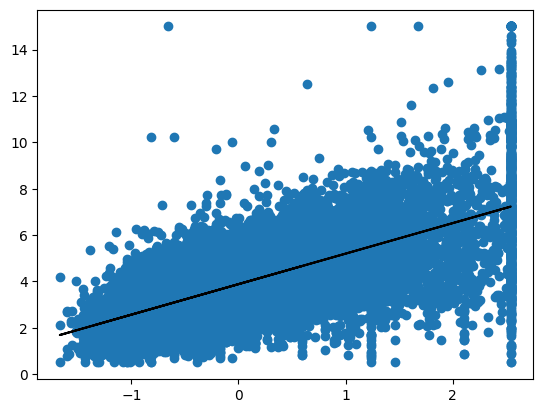

In [81]:
plt.scatter(X_train_scaled,y_train)
plt.plot(X_train_scaled,reg.predict(X_train_scaled),color='black')

In [82]:
#predicting the test data
y_pred=reg.predict(X_test)

C:\Users\yuvra\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [87]:
# to analyse the performance using performance metrics models
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,root_mean_squared_error
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2s=r2_score(y_test,y_pred)
print(mae,'\n',mse,'\n',rmse,'\n',r2s)


271353.7646720767 
 97043954349.76132 
 311518.78651176294 
 -27720220962.183765


In [89]:
#OLS linear regression
import statsmodels.api as sm

In [90]:
model=sm.OLS(y_train,X_train_scaled).fit()

In [91]:
model.predict(X_test_scaled)

array([-1.01176424, -1.49632058,  0.325337  , ...,  0.36876422,
        0.11277219,  1.48415807], shape=(4128,))

In [93]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:          median_income   R-squared (uncentered):                   0.093
Model:                            OLS   Adj. R-squared (uncentered):              0.093
Method:                 Least Squares   F-statistic:                              1687.
Date:                Fri, 19 Jun 2026   Prob (F-statistic):                        0.00
Time:                        17:15:54   Log-Likelihood:                         -46799.
No. Observations:               16512   AIC:                                  9.360e+04
Df Residuals:                   16511   BIC:                                  9.361e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [94]:
#nopw predicting in new data
reg.predict(scaler.transform([[4894]]))

C:\Users\yuvra\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([1.5697765])